In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

ModuleNotFoundError: No module named 'wordcloud'

In [4]:
netflix_df = pd.read_csv("NetFlix.csv.zip")
netflix_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...


In [5]:
import os

os.getcwd()


'C:\\Users\\HP\\netflix'

In [6]:
os.listdir()


['.git', '.ipynb_checkpoints', 'NetFlix.csv.zip', 'netflix.ipynb']

In [7]:
netflix_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   int64 
 10  genres        7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(2), object(10)
memory usage: 730.2+ KB


In [8]:

netflix_df.isnull().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
genres             0
description        0
dtype: int64

insights director, country and cast have a lot of missing values and we have to handle the missing values 

In [9]:
netflix_df['director'] = netflix_df['director'].fillna('Unknown')
netflix_df['cast'] = netflix_df['cast'].fillna('Unknown')

In [10]:
mode_country = netflix_df['country'].mode()[0]
netflix_df['country'] =  netflix_df['country'].fillna(mode_country)

In [11]:
netflix_df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           7
duration         0
genres           0
description      0
dtype: int64

and we have to handle remaining column we drop the colunm
since the number is small 9less than 0.2% of data ) dropping them is a safe option 

In [12]:
netflix_df.dropna(subset = ['date_added','rating','duration'],inplace = True)

In [13]:

netflix_df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
genres          0
description     0
dtype: int64

data type inconsistency in the date_added column

In [17]:
netflix_df['data_added'] = pd.to_datetime(netflix_df['date_added'],format='mixed',dayfirst=False)

feature engineering

In [23]:
# create new feature for year and month added 
netflix_df['year_added'] = netflix_df['date_added'].dt.year
netflix_df['month_added'] = netflix_df['date_added'].dt.month

In [19]:
print(netflix_df['date_added'].dtype)

object


In [21]:
netflix_df['date_added'] = pd.to_datetime(
    netflix_df['date_added'],
    errors='coerce'
)

In [22]:
netflix_df['year_added'] = netflix_df['date_added'].dt.year
netflix_df['month_added'] = netflix_df['date_added'].dt.month

In [24]:
 # verify our cleaning and transformation
print("missing values after cleaning :")
print(netflix_df.isnull().sum())
print("ndata types after transformation")
print(netflix_df.dtypes)

missing values after cleaning :
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
genres          0
description     0
data_added      0
year_added      0
month_added     0
dtype: int64
ndata types after transformation
show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                 int64
genres                  object
description             object
data_added      datetime64[ns]
year_added               int32
month_added              int32
dtype: object


exploratory data analysis
univariate work on one feature  bivariate work on two feature
trend -> revenue (is this increasing or decreasing )
Line plot (month , year )
distribution of 2-3 caterpical data points
->pie chart 
distribution of any  continuous data  
-> histogram (symmetic or skewed


In [25]:
type_counts = netflix_df['type'].value_counts()
print(type_counts)

type
Movie      5372
TV Show    2398
Name: count, dtype: int64


insight - the netflix library is highly dominated by Movies 
which 

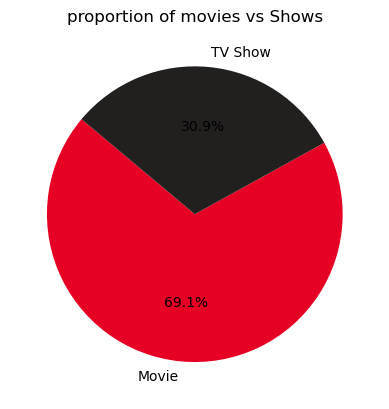

In [26]:
plt.pie(type_counts, labels=type_counts.index,autopct = '%1.1f%%',startangle = 140 , colors =['#e60023','#221f1f'])
plt.title('proportion of movies vs Shows')
plt.ylabel('')
plt.show()

In [ ]:
how has the content added the time ?
# group data by year and content type

In [28]:
content_over_time = netflix_df.groupby(['year_added','type']).size().unstack().fillna(0)
print(content_over_time)

type         Movie  TV Show
year_added                 
2008           1.0      1.0
2009           2.0      0.0
2010           1.0      0.0
2011          13.0      0.0
2012           3.0      0.0
2013           6.0      5.0
2014          19.0      6.0
2015          58.0     30.0
2016         256.0    184.0
2017         861.0    361.0
2018        1255.0    429.0
2019        1497.0    656.0
2020        1312.0    697.0
2021          88.0     29.0


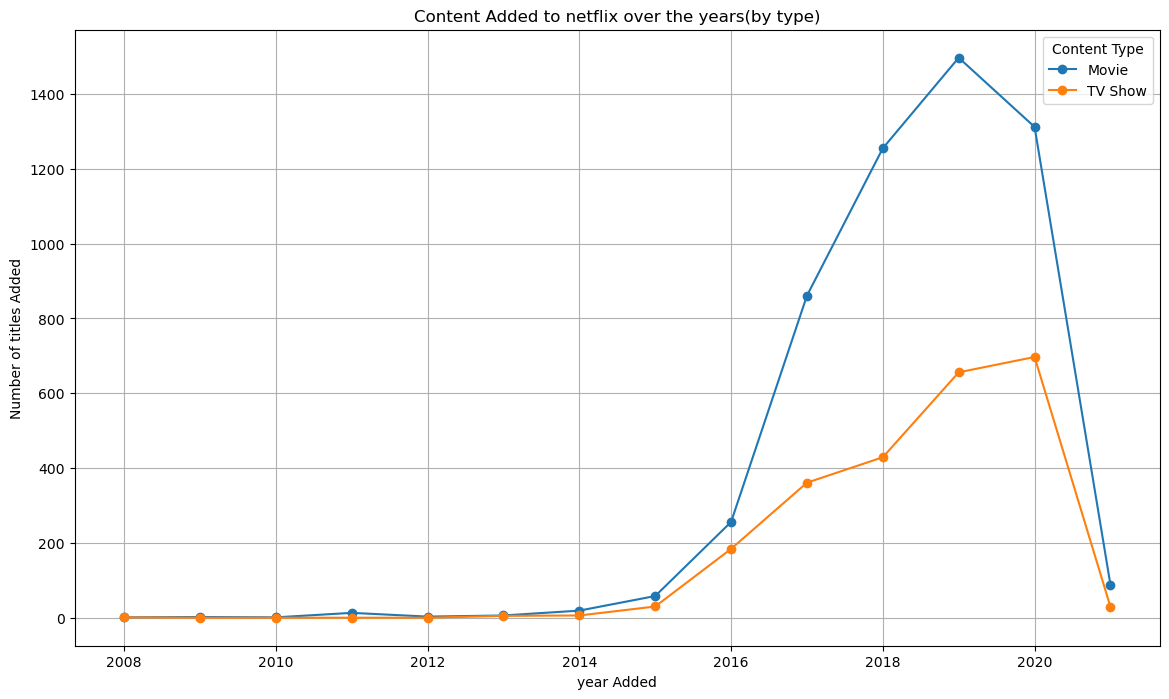

In [34]:
content_over_time.plot(kind ='line', marker ='o', figsize =(14,8))
plt.title('Content Added to netflix over the years(by type)')
plt.xlabel('year Added')
plt.ylabel('Number of titles Added')
plt.legend(title='Content Type')
plt.grid(True)
plt.show()






Insights -  by seperating movies and tv shows we can clearly see that while both grew significantly from year 2008 to 2020
the addition of movies accelerated more dramatically in th eyear 2019 especially in the year 2019 the growth in the TV shows has beemn more steady. there appears
to be slight shutdown in content additions in the year 2020 and 2021 which could be due to the peak of covid-19
 at that time

In [37]:
# split the 'listed_in ' column and explode it 
genres = netflix_df.assign(genre = netflix_df ['genres'].str.split(',')).explode('genre')
genres

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,data_added,year_added,month_added,genre
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020-08-14,2020,8,International TV Shows
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020-08-14,2020,8,TV Dramas
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020-08-14,2020,8,TV Sci-Fi & Fantasy
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,2017-12-15,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...,2017-12-15,2017,12,Horror Movies
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,2017-12-15,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...,2017-12-15,2017,12,International Movies
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7785,s998,Movie,Blue Jasmine,Woody Allen,"Cate Blanchett, Sally Hawkins, Alec Baldwin, L...",United States,2019-03-08,2013,PG-13,98,"Comedies, Dramas, Independent Movies",The high life leads to high anxiety for a fash...,2019-03-08,2019,3,Dramas
7785,s998,Movie,Blue Jasmine,Woody Allen,"Cate Blanchett, Sally Hawkins, Alec Baldwin, L...",United States,2019-03-08,2013,PG-13,98,"Comedies, Dramas, Independent Movies",The high life leads to high anxiety for a fash...,2019-03-08,2019,3,Independent Movies
7786,s999,Movie,Blue Jay,Alex Lehmann,"Sarah Paulson, Mark Duplass, Clu Gulager",United States,2016-12-06,2016,TV-MA,81,"Dramas, Independent Movies, Romantic Movies",Two former high school sweethearts unexpectedl...,2016-12-06,2016,12,Dramas
7786,s999,Movie,Blue Jay,Alex Lehmann,"Sarah Paulson, Mark Duplass, Clu Gulager",United States,2016-12-06,2016,TV-MA,81,"Dramas, Independent Movies, Romantic Movies",Two former high school sweethearts unexpectedl...,2016-12-06,2016,12,Independent Movies


In [35]:
print(netflix_df.columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genres', 'description',
       'data_added', 'year_added', 'month_added'],
      dtype='object')


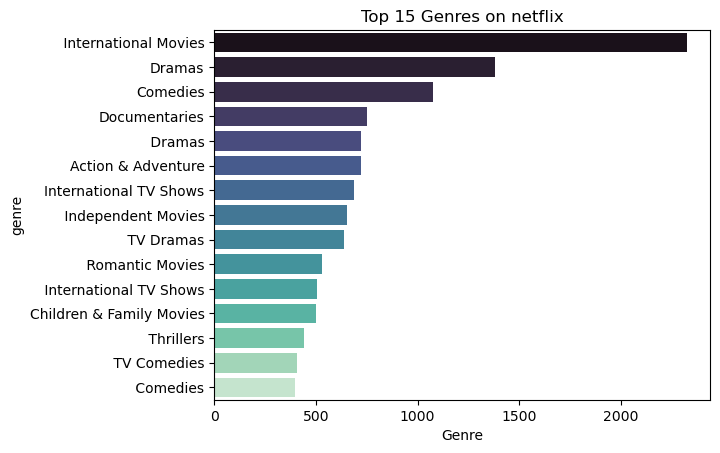

In [39]:
# get the top 15 genres and their counts
top_genres_counts = genres['genre'].value_counts().reset_index()
# rename columns for clarity
top_genres_counts.columns = ['genre','count']
# select only the top 15 for plotting
top_genres_counts_plot = top_genres_counts.head(15)

sns.barplot(y='genre',x ='count', data= top_genres_counts_plot, palette='mako',hue='genre',
           legend=False)
plt.title('Top 15 Genres on netflix')
plt.xlabel('Count')
plt.xlabel('Genre')
plt.show()

In [ ]:
# distribution of content duration 

In [11]:
movies_df = netflix_df[netflix_df['type']=='Movie'].copy()
tv_shows_df = netflix_df[netflix_df['type']=='TV Shows'].copy()

In [9]:
movies_df
tv_shows_df


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description


In [12]:
movies_df = netflix_df[netflix_df['type']=='Movie'].copy()
tv_shows_df = netflix_df[netflix_df['type']=='TV Shows'].copy()
# clean and convert duration for movies
movies_df['seasons'] = tv_shows_df['duration'].str.replace('Seasons','').astype(int)

AttributeError: Can only use .str accessor with string values!